# SHAP Explainability — LightGBM Model

This notebook applies SHAP to interpret the final LightGBM model used for flight delay prediction.

The goal is to understand which features contribute the most to the model predictions and how they influence the probability of delay.

In [1]:
# Imports

import pandas as pd
import numpy as np
import joblib
import shap

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (10, 6)

/Users/Cliscia-Aula/.pyenv/versions/3.12.9/envs/flight-risk/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Data and Trained Model

df = pd.read_parquet("../.data/flights_features_updated.parquet")

model = joblib.load("../.data/model/lgbm_binary.pkl")

print(f"Dataset shape: {df.shape}")
print("Model loaded successfully.")

Dataset shape: (2964978, 57)
Model loaded successfully.


In [3]:
# Define Features, Target and Temporal Spli

TARGET = "is_delayed"
METADATA = ["dep_scheduled"]

X = df.drop(columns=[TARGET] + METADATA)
y = df[TARGET]

VAL_CUTOFF = "2025-07-01"

dates = df["dep_scheduled"]

train_mask = dates.dt.year.isin([2022, 2023, 2024])
val_mask = (~train_mask) & (dates < VAL_CUTOFF)
test_mask = (~train_mask) & (dates >= VAL_CUTOFF)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train:      2,193,914 rows
Validation: 379,819 rows
Test:       391,245 rows

Test target distribution:
is_delayed
0   83.920
1   16.080
Name: proportion, dtype: float64


In [4]:
# Load preprocessing artifacts

encoders = joblib.load("../.data/model/encoders.pkl")
airline_hour_stats = joblib.load("../.data/model/airline_hour_stats.pkl")
route_stats = joblib.load("../.data/model/route_stats.pkl")
airports_reference = pd.read_csv("../.data/model/airports_reference.csv")

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


In [5]:
print(X_test.shape)

X_test.head()


(391245, 55)


,airline_icao,origin_icao,destination_icao,origin_elevation_ft,origin_region,destination_elevation_ft,destination_region,origin_wx_temperature_2m,origin_wx_precipitation,origin_wx_windspeed_10m,origin_wx_windgusts_10m,origin_wx_cloudcover,origin_wx_surface_pressure,destination_wx_temperature_2m,destination_wx_precipitation,destination_wx_windspeed_10m,destination_wx_windgusts_10m,destination_wx_cloudcover,destination_wx_surface_pressure,dep_day_of_year,dep_is_weekend,dep_hour_sin,dep_hour_cos,dep_dow_sin,dep_dow_cos,dep_month_sin,dep_month_cos,dep_time_block,dep_is_peak_hour,dep_is_holiday,route,region_pair,distance_km,flight_range,elevation_diff_ft,origin_airport_size,destination_airport_size,is_trunk_route,scheduled_duration_min,origin_hourly_flights,destination_hourly_arrivals,total_hourly_congestion,origin_wx_condition,destination_wx_condition,origin_wx_is_fog,origin_wx_is_rain,origin_wx_is_storm,destination_wx_is_fog,destination_wx_is_rain,destination_wx_is_storm,route_hist_delay_mean,route_hist_delay_std,route_hist_delay_rate,airline_hour_delay_rate,airline_hour_delay_mean
2523791,GLO,SBBE,SBSN,54.000,BR-PA,198.000,BR-PA,23.950,0.200,7.858,13.680,51.000,1014.017,24.450,2.100,14.767,28.080,99.000,1007.292,182,0,0.000,1.000,0.782,0.623,-0.500,-0.866,early_morning,0,0,SBBE_SBSN,BR-PA_BR-PA,711.524,medium,144.000,3.000,2.000,0,85.000,3,2,5,rain,rain,0,1,0,0,1,0,2.829,22.364,0.114,0.215,6.457
2573734,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,18.350,0.000,3.976,17.280,0.000,947.195,22.681,0.000,8.778,25.920,13.000,1021.646,204,0,0.707,-0.707,0.975,-0.223,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,12,5,17,clear,clear,0,0,0,0,0,0,4.217,20.655,0.136,0.110,2.788
2573735,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,16.550,0.000,18.962,41.040,6.000,947.490,21.131,0.100,6.016,18.720,97.000,1024.143,205,0,0.707,-0.707,0.434,-0.901,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,12,5,17,clear,rain,0,0,0,0,1,0,4.217,20.655,0.136,0.110,2.788
2573736,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,16.800,0.000,9.907,25.920,96.000,945.700,22.081,0.000,4.847,18.360,99.000,1021.245,206,0,0.707,-0.707,-0.434,-0.901,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,12,5,17,cloudy,cloudy,0,0,0,0,0,0,4.217,20.655,0.136,0.110,2.788
2573737,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,15.550,0.000,8.906,27.360,4.000,945.389,21.331,0.000,2.886,19.080,57.000,1021.644,207,1,0.707,-0.707,-0.975,-0.223,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,10,4,14,clear,cloudy,0,0,0,0,0,0,4.217,20.655,0.136,0.110,2.788


In [6]:
X_test.dtypes

airline_icao                            str
origin_icao                             str
destination_icao                        str
origin_elevation_ft                 float64
origin_region                           str
destination_elevation_ft            float64
destination_region                      str
origin_wx_temperature_2m            float32
origin_wx_precipitation             float32
origin_wx_windspeed_10m             float32
origin_wx_windgusts_10m             float32
origin_wx_cloudcover                float32
origin_wx_surface_pressure          float32
destination_wx_temperature_2m       float32
destination_wx_precipitation        float32
destination_wx_windspeed_10m        float32
destination_wx_windgusts_10m        float32
destination_wx_cloudcover           float32
destination_wx_surface_pressure     float32
dep_day_of_year                       int32
dep_is_weekend                        int64
dep_hour_sin                        float64
dep_hour_cos                    

In [7]:
# Encode Categorical Features for Model Input

CAT_COLS = [
    "airline_icao", "origin_icao", "destination_icao",
    "origin_region", "destination_region",
    "route", "region_pair", "flight_range",
    "dep_time_block",
    "origin_wx_condition", "destination_wx_condition",
]

X_test_encoded = X_test.copy()

for col in CAT_COLS:
    if col in X_test_encoded.columns:
        X_test_encoded[col] = X_test_encoded[col].astype(str)
        X_test_encoded[col] = encoders[col].transform(X_test_encoded[col])

print(X_test_encoded.shape)
print(X_test_encoded.dtypes.value_counts())

(391245, 55)
int64      24
float64    18
float32    12
int32       1
Name: count, dtype: int64


In [8]:
print(model.n_features_)

55


In [9]:
print(list(X_test_encoded.columns) == list(model.feature_name_))

True


In [10]:
# Test Model Predictions

y_pred = model.predict(X_test_encoded)
y_prob = model.predict_proba(X_test_encoded)[:, 1]

print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_prob.shape)

print("\nFirst predictions:")
print(y_pred[:10])

print("\nFirst probabilities:")
print(y_prob[:10])

Prediction shape: (391245,)
Probability shape: (391245,)

First predictions:
[0 0 0 0 0 0 0 0 0 0]

First probabilities:
[0.20910619 0.27622261 0.3353743  0.47835655 0.44840631 0.36608145
 0.2789844  0.30538748 0.37771886 0.47816556]


In [11]:
# Create SHAP Explainer

explainer = shap.TreeExplainer(model)

print("SHAP Explainer created successfully.")

SHAP Explainer created successfully.


In [12]:
# Create Sample for SHAP

X_sample = X_test_encoded.sample(
    n=3000,
    random_state=42
)

print(X_sample.shape)

(3000, 55)


In [13]:
# Calculate SHAP Values

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


/Users/Cliscia-Aula/.pyenv/versions/3.12.9/envs/flight-risk/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


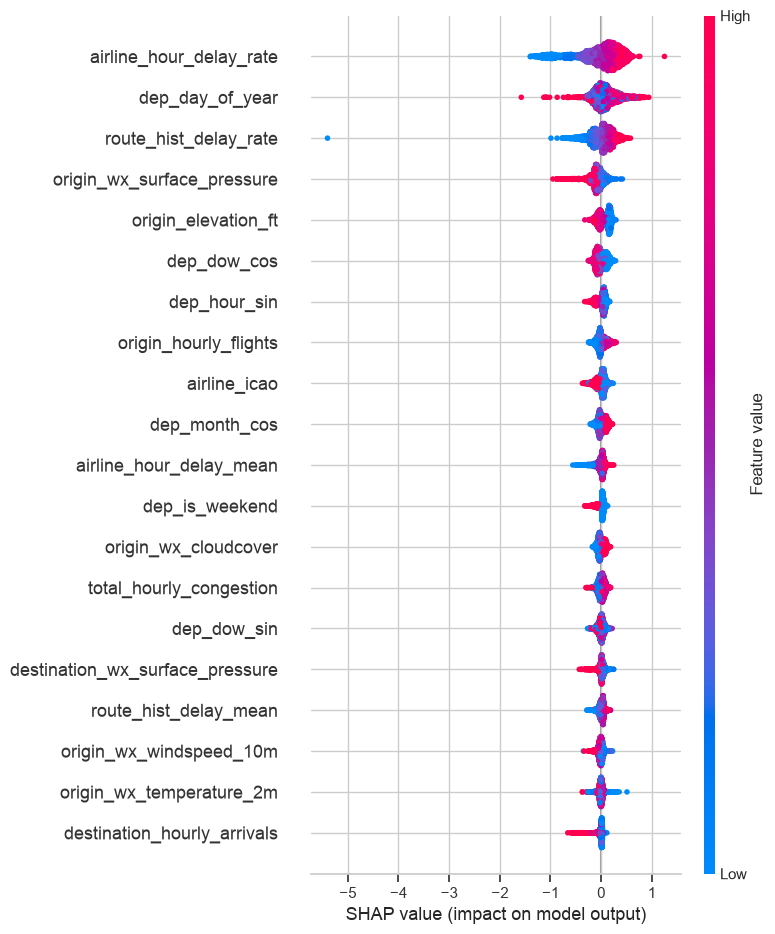

In [14]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_sample
)

### Interpretation

The Summary Plot ranks features by their average impact on the model output.

In this model, historical airline delay rate and historical route delay rate are the most influential predictors.

Higher values of these variables generally increase the probability of a delayed flight, indicating that the model successfully learned operational delay patterns rather than relying only on airport or airline identifiers.

In [15]:
# Interactive SHAP Feature Importance

import plotly.express as px

shap_importance = (
    pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .head(20)
)

fig = px.bar(
    shap_importance.sort_values("mean_abs_shap"),
    x="mean_abs_shap",
    y="feature",
    orientation="h",
    title="Top 20 Features by Mean Absolute SHAP Value",
    labels={
        "mean_abs_shap": "Mean |SHAP value|",
        "feature": ""
    },
    height=750
)

fig.update_layout(
    template="plotly_white",
    font=dict(size=15),
    title_x=0.5,
    margin=dict(l=230, r=40, t=70, b=50),
    yaxis=dict(
        tickfont=dict(size=14)
    ),
    xaxis=dict(
        title_font=dict(size=15),
        tickfont=dict(size=13)
    )
)

fig.show()

### Interpretation

This chart ranks the features according to their average absolute SHAP value, representing their overall contribution to the model's predictions.

The most influential variables are historical operational indicators, such as **airline_hour_delay_rate** and **route_hist_delay_rate**, suggesting that past delay patterns are the strongest predictors of future flight delays. Temporal features, including **dep_day_of_year**, also play an important role, while weather-related variables contribute with a smaller but still meaningful impact.

Overall, the model relies primarily on operational history and temporal information rather than airport or airline identifiers, indicating that it has learned meaningful patterns associated with flight delays.

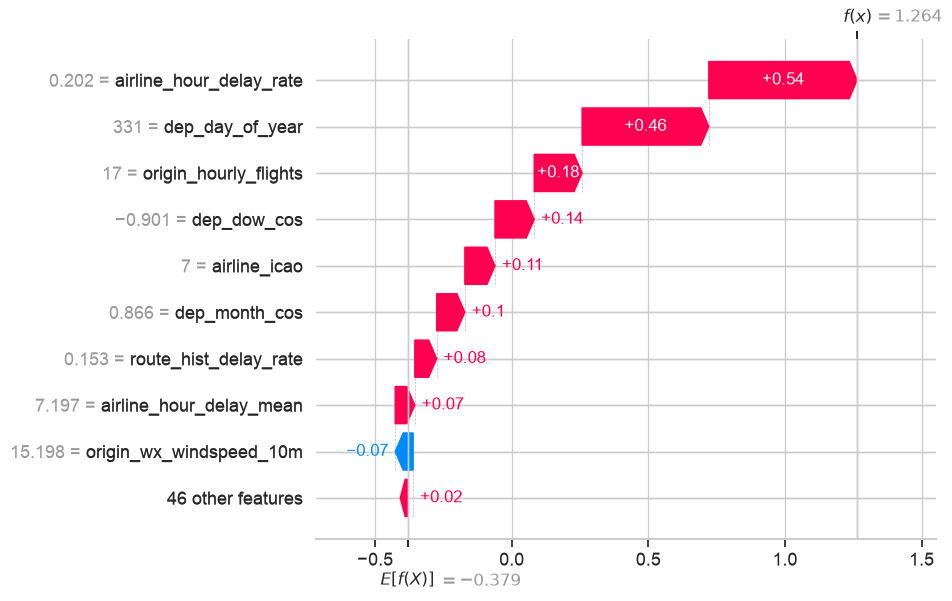

In [16]:
# Select Example Prediction

y_sample = y_test.loc[X_sample.index]
sample_index = np.where(y_sample == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[sample_index],
        feature_names=X_sample.columns
    )
)

### Interpretation

This Waterfall Plot explains one delayed flight selected from the SHAP sample. The model starts from the baseline prediction and each feature pushes the prediction either toward or away from a delay.

For this flight, **airline_hour_delay_rate** and **dep_day_of_year** were the strongest positive contributors, meaning that historical airline delay behavior and seasonal timing increased the model output toward a delayed-flight prediction. **origin_hourly_flights** and **route_hist_delay_rate** also contributed positively, suggesting that airport activity and route delay history were relevant for this case.

Some variables, such as **origin_wx_windspeed_10m**, slightly reduced the prediction. Overall, this individual explanation shows that the model decision was mainly driven by historical operational patterns and temporal factors.

In [17]:
# Interactive SHAP Dependence Plot

feature = "airline_hour_delay_rate"

dependence_df = pd.DataFrame({
    feature: X_sample[feature],
    "shap_value": shap_values[:, list(X_sample.columns).index(feature)]
})

fig = px.scatter(
    dependence_df,
    x=feature,
    y="shap_value",
    title="SHAP Dependence Plot — Airline Historical Delay Rate",
    labels={
        feature: "Airline historical delay rate",
        "shap_value": "SHAP value"
    },
    opacity=0.65,
    height=600
)

fig.update_layout(
    template="plotly_white",
    font=dict(size=14),
    title_x=0.5,
    margin=dict(l=80, r=40, t=70, b=60)
)

fig.show()

### Interpretation

This dependence plot shows how **airline_hour_delay_rate** affects the model output across the sampled flights.

As the historical delay rate for an airline at a given hour increases, the SHAP value generally becomes more positive. This indicates that higher historical delay rates push the model toward predicting a delayed flight.

The relationship is clearly increasing, suggesting that the model learned a meaningful operational pattern: airlines with worse delay performance at specific hours tend to contribute more strongly to future delay predictions.

## Final Conclusions

SHAP analysis showed that the LightGBM model relies mainly on historical operational patterns to predict flight delays.

The most important features were related to airline delay history, route delay history, seasonality, and airport activity. This suggests that the model is not relying only on static identifiers, but is learning meaningful patterns associated with flight operations.

The individual explanation confirmed that a delayed-flight prediction was mainly driven by historical airline behavior, route performance, and temporal characteristics.

Overall, SHAP improved the interpretability of the model and helped validate that the model predictions are aligned with real operational factors.

# LLM-Powered Explanation using SHAP

In this section, we use a Large Language Model (LLM) to transform technical SHAP outputs into a clear explanation for the final user.

Instead of asking the LLM to explain the prediction freely, we provide structured evidence from SHAP, including the predicted delay probability and the main factors that increased or reduced the model output.

This helps keep the explanation grounded in the model behavior while making it easier for passengers to understand the reason behind each prediction.

In [18]:
# Check objects available for LLM explanation step

print("X_sample shape:", X_sample.shape)
print("SHAP values shape:", shap_values.shape)
print("Expected value:", explainer.expected_value)
print("Model loaded:", model is not None)

X_sample shape: (3000, 55)
SHAP values shape: (3000, 55)
Expected value: -0.37870379892214295
Model loaded: True


## Extracting SHAP Evidence for LLM

Before generating a natural language explanation, we first extract the most influential features identified by SHAP.

Rather than sending all model inputs to the LLM, we provide only the strongest positive and negative contributors, together with their feature values and SHAP contributions. This produces shorter, more focused, and evidence-based explanations.

In [19]:
# Select one example flight from the SHAP sample

sample_index = 0

example_flight = X_sample.iloc[sample_index]
example_shap_values = shap_values[sample_index]

print("Selected sample index:", sample_index)
print("Number of features:", len(example_flight))
print("Number of SHAP values:", len(example_shap_values))

example_flight.head()

Selected sample index: 0
Number of features: 55
Number of SHAP values: 55


airline_icao             7.000
origin_icao             96.000
destination_icao        86.000
origin_elevation_ft   2631.000
origin_region           30.000
Name: 2859739, dtype: float64

## Build SHAP Evidence Table

In [20]:
def build_shap_evidence(
    feature_names,
    feature_values,
    shap_values,
):
    """
    Build a SHAP evidence table for a single flight prediction.
    Returns a DataFrame containing the feature names, feature values,
    SHAP values and their impact on the prediction.
    """


    shap_evidence = pd.DataFrame({
        "feature": feature_names,
        "feature_value": feature_values,
        "shap_value": shap_values
    })

    shap_evidence["abs_shap_value"] = (
        shap_evidence["shap_value"].abs()
    )

    shap_evidence["effect"] = shap_evidence["shap_value"].apply(
        lambda x: ( "aumenta o risco de atraso"
                   if x > 0 else
                   "reduz o risco de atraso"
        )
    )

    shap_evidence = shap_evidence.sort_values(
        by="abs_shap_value",
        ascending=False,
    )

    return shap_evidence

In [21]:
# Test SHAP Evidence Builder
shap_evidence = build_shap_evidence(
    feature_names=X_sample.columns,
    feature_values=example_flight.values,
    shap_values=example_shap_values,
)

shap_evidence.head(10)

,feature,feature_value,shap_value,abs_shap_value,effect
53,airline_hour_delay_rate,0.202,0.543,0.543,aumenta o risco de atraso
19,dep_day_of_year,331.000,0.464,0.464,aumenta o risco de atraso
39,origin_hourly_flights,17.000,0.175,0.175,aumenta o risco de atraso
24,dep_dow_cos,-0.901,0.143,0.143,aumenta o risco de atraso
0,airline_icao,7.000,0.110,0.110,aumenta o risco de atraso
26,dep_month_cos,0.866,0.103,0.103,aumenta o risco de atraso
52,route_hist_delay_rate,0.153,0.080,0.080,aumenta o risco de atraso
54,airline_hour_delay_mean,7.197,0.072,0.072,aumenta o risco de atraso
9,origin_wx_windspeed_10m,15.198,-0.066,0.066,reduz o risco de atraso
18,destination_wx_surface_pressure,1015.648,-0.064,0.064,reduz o risco de atraso


In [22]:
def select_top_shap_features(
    shap_evidence: pd.DataFrame,
    top_k: int = 3,
) -> pd.DataFrame:
    """
    Select the most influential SHAP features for a single prediction.

    Returns the top features sorted by absolute SHAP contribution.
    """

    return shap_evidence.head(top_k)

In [23]:
top_features = select_top_shap_features(
    shap_evidence=shap_evidence,
    top_k=3,
)

In [24]:
features = pd.DataFrame({
    "feature": X_sample.columns
})

features

,feature
0,airline_icao
1,origin_icao
2,destination_icao
3,origin_elevation_ft
4,origin_region
5,destination_elevation_ft
6,destination_region
7,origin_wx_temperature_2m
8,origin_wx_precipitation
9,origin_wx_windspeed_10m


In [25]:
# Build LLM Context

FEATURE_DESCRIPTIONS = {
    "airline_icao": "companhia aérea responsável pelo voo",
    "origin_icao": "aeroporto de origem do voo",
    "destination_icao": "aeroporto de destino do voo",
    "origin_elevation_ft": "altitude do aeroporto de origem",
    "origin_region": "região do aeroporto de origem",
    "destination_elevation_ft": "altitude do aeroporto de destino",
    "destination_region": "região do aeroporto de destino",

    "origin_wx_temperature_2m": "temperatura no aeroporto de origem",
    "origin_wx_precipitation": "precipitação no aeroporto de origem",
    "origin_wx_windspeed_10m": "velocidade do vento no aeroporto de origem",
    "origin_wx_windgusts_10m": "rajadas de vento no aeroporto de origem",
    "origin_wx_cloudcover": "cobertura de nuvens no aeroporto de origem",
    "origin_wx_surface_pressure": "pressão atmosférica no aeroporto de origem",

    "destination_wx_temperature_2m": "temperatura no aeroporto de destino",
    "destination_wx_precipitation": "precipitação no aeroporto de destino",
    "destination_wx_windspeed_10m": "velocidade do vento no aeroporto de destino",
    "destination_wx_windgusts_10m": "rajadas de vento no aeroporto de destino",
    "destination_wx_cloudcover": "cobertura de nuvens no aeroporto de destino",
    "destination_wx_surface_pressure": "pressão atmosférica no aeroporto de destino",

    "dep_day_of_year": "período do ano em que o voo está programado",
    "dep_is_weekend": "indica se o voo ocorre em um fim de semana",
    "dep_hour_sin": "representação cíclica do horário de partida",
    "dep_hour_cos": "representação cíclica do horário de partida",
    "dep_dow_sin": "representação cíclica do dia da semana",
    "dep_dow_cos": "representação cíclica do dia da semana",
    "dep_month_sin": "representação cíclica do mês da viagem",
    "dep_month_cos": "representação cíclica do mês da viagem",
    "dep_time_block": "período do dia em que o voo está programado",
    "dep_is_peak_hour": "indica se o voo ocorre em horário de maior movimento",
    "dep_is_holiday": "indica se o voo ocorre em feriado",

    "route": "rota do voo entre origem e destino",
    "region_pair": "combinação entre a região de origem e a região de destino",
    "distance_km": "distância aproximada da rota em quilômetros",
    "flight_range": "categoria da distância do voo",
    "elevation_diff_ft": "diferença de altitude entre origem e destino",
    "origin_airport_size": "porte do aeroporto de origem",
    "destination_airport_size": "porte do aeroporto de destino",
    "is_trunk_route": "indica se a rota é uma rota aérea de alta demanda",
    "scheduled_duration_min": "duração programada do voo em minutos",

    "origin_hourly_flights": "volume de voos programados no aeroporto de origem neste horário",
    "destination_hourly_arrivals": "volume de chegadas programadas no aeroporto de destino neste horário",
    "total_hourly_congestion": "nível total de congestionamento aéreo no horário do voo",

    "origin_wx_condition": "condição climática geral no aeroporto de origem",
    "destination_wx_condition": "condição climática geral no aeroporto de destino",
    "origin_wx_is_fog": "indica presença de neblina no aeroporto de origem",
    "origin_wx_is_rain": "indica presença de chuva no aeroporto de origem",
    "origin_wx_is_storm": "indica presença de tempestade no aeroporto de origem",
    "destination_wx_is_fog": "indica presença de neblina no aeroporto de destino",
    "destination_wx_is_rain": "indica presença de chuva no aeroporto de destino",
    "destination_wx_is_storm": "indica presença de tempestade no aeroporto de destino",

    "route_hist_delay_mean": "atraso médio histórico dos voos nesta rota",
    "route_hist_delay_std": "variação histórica dos atrasos nesta rota",
    "route_hist_delay_rate": "taxa histórica de atraso desta rota",
    "airline_hour_delay_rate": "taxa histórica de atraso da companhia aérea neste horário",
    "airline_hour_delay_mean": "atraso médio histórico da companhia aérea neste horário",
}

In [26]:
len(FEATURE_DESCRIPTIONS)

55

In [27]:
def build_llm_prompt(
    prediction_probability: float,
    llm_context: list[dict],
) -> str:
    """
    Build the prompt used by the LLM to explain one prediction.
    """

    factors_text = ""

    for feature in llm_context:
        factors_text += (
            f"- {feature['description']}: "
            f"valor={feature['value']}, "
            f"contribuição={feature['shap_value']}, "
            f"efeito={feature['effect']}\n"
        )

    prompt = f"""
Você é um assistente especializado em aviação e seu objetivo é explicar previsões de atraso de voos para passageiros.

O modelo estimou uma probabilidade de atraso de {prediction_probability:.1%}.

Principais fatores que influenciaram esta previsão:
{factors_text}

Instruções para a resposta:

Responda em português do Brasil.
Baseie sua resposta exclusivamente nas informações fornecidas acima.
Não faça suposições.
Não cite fatores que não aparecem na lista.
Não ofereça recomendações que dependam de informações inexistentes.
Não mencione SHAP, LightGBM, Inteligência Artificial, Machine Learning ou qualquer termo técnico.
Utilize linguagem simples, clara, objetiva e amigável, adequada para passageiros.
Caso a probabilidade de atraso seja baixa, não utilize linguagem alarmista.
Caso a probabilidade de atraso seja alta, informe isso de forma objetiva, sem exageros ou previsões categóricas.
Escreva apenas um parágrafo, com no máximo 120 palavras.
"""

    return prompt.strip()

In [28]:
def build_llm_context(
    top_features: pd.DataFrame,
    feature_descriptions: dict,
) -> list[dict]:
    """
    Build a structured context for the LLM.
    """

    llm_context = []

    for _, row in top_features.iterrows():
        feature_name = row["feature"]

        llm_context.append({
            "feature": feature_name,
            "description": feature_descriptions.get(
                feature_name,
                feature_name
            ),
            "value": round(float(row["feature_value"]), 4),
            "shap_value": round(float(row["shap_value"]), 4),
            "effect": row["effect"],
        })

    return llm_context

In [29]:
llm_context = build_llm_context(
    top_features=top_features,
    feature_descriptions=FEATURE_DESCRIPTIONS,
)

llm_context

[{'feature': 'airline_hour_delay_rate',
  'description': 'taxa histórica de atraso da companhia aérea neste horário',
  'value': 0.2019,
  'shap_value': 0.5432,
  'effect': 'aumenta o risco de atraso'},
 {'feature': 'dep_day_of_year',
  'description': 'período do ano em que o voo está programado',
  'value': 331.0,
  'shap_value': 0.4637,
  'effect': 'aumenta o risco de atraso'},
 {'feature': 'origin_hourly_flights',
  'description': 'volume de voos programados no aeroporto de origem neste horário',
  'value': 17.0,
  'shap_value': 0.1753,
  'effect': 'aumenta o risco de atraso'}]

In [30]:
prompt = build_llm_prompt(
    prediction_probability=0.72,
    llm_context=llm_context,
)

print(prompt)

Você é um assistente especializado em aviação e seu objetivo é explicar previsões de atraso de voos para passageiros.

O modelo estimou uma probabilidade de atraso de 72.0%.

Principais fatores que influenciaram esta previsão:
- taxa histórica de atraso da companhia aérea neste horário: valor=0.2019, contribuição=0.5432, efeito=aumenta o risco de atraso
- período do ano em que o voo está programado: valor=331.0, contribuição=0.4637, efeito=aumenta o risco de atraso
- volume de voos programados no aeroporto de origem neste horário: valor=17.0, contribuição=0.1753, efeito=aumenta o risco de atraso


Instruções para a resposta:

Responda em português do Brasil.
Baseie sua resposta exclusivamente nas informações fornecidas acima.
Não faça suposições.
Não cite fatores que não aparecem na lista.
Não ofereça recomendações que dependam de informações inexistentes.
Não mencione SHAP, LightGBM, Inteligência Artificial, Machine Learning ou qualquer termo técnico.
Utilize linguagem simples, clara,

In [31]:
def call_gemini(
    prompt: str,
) -> str:
    """
    Send the prompt to Gemini and return the generated explanation.
    """


In [32]:
def generate_delay_explanation(
    feature_names,
    feature_values,
    shap_values,
    prediction_probability: float,
    feature_descriptions: dict,
    top_k: int = 3,
) -> str:
    """
    Generate a natural language explanation for one flight prediction.
    """

    shap_evidence = build_shap_evidence(
        feature_names=feature_names,
        feature_values=feature_values,
        shap_values=shap_values,
    )

    top_features = select_top_shap_features(
        shap_evidence=shap_evidence,
        top_k=top_k,
    )

    llm_context = build_llm_context(
        top_features=top_features,
        feature_descriptions=feature_descriptions,
    )

    prompt = build_llm_prompt(
        prediction_probability=prediction_probability,
        llm_context=llm_context,
    )

    return prompt

In [33]:
final_prompt = generate_delay_explanation(
    feature_names=X_sample.columns,
    feature_values=example_flight.values,
    shap_values=example_shap_values,
    prediction_probability=0.72,
    feature_descriptions=FEATURE_DESCRIPTIONS,
    top_k=3,
)

print(final_prompt)

Você é um assistente especializado em aviação e seu objetivo é explicar previsões de atraso de voos para passageiros.

O modelo estimou uma probabilidade de atraso de 72.0%.

Principais fatores que influenciaram esta previsão:
- taxa histórica de atraso da companhia aérea neste horário: valor=0.2019, contribuição=0.5432, efeito=aumenta o risco de atraso
- período do ano em que o voo está programado: valor=331.0, contribuição=0.4637, efeito=aumenta o risco de atraso
- volume de voos programados no aeroporto de origem neste horário: valor=17.0, contribuição=0.1753, efeito=aumenta o risco de atraso


Instruções para a resposta:

Responda em português do Brasil.
Baseie sua resposta exclusivamente nas informações fornecidas acima.
Não faça suposições.
Não cite fatores que não aparecem na lista.
Não ofereça recomendações que dependam de informações inexistentes.
Não mencione SHAP, LightGBM, Inteligência Artificial, Machine Learning ou qualquer termo técnico.
Utilize linguagem simples, clara,

In [36]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

assert api_key is not None, "GEMINI_API_KEY not found. Check your .env file."

## Generate LLM Response

In [38]:
from langchain_google_genai import ChatGoogleGenerativeAI


def generate_llm_response(
    prompt: str,
    api_key: str,
    model_name: str = "gemini-2.5-flash",
    temperature: float = 0,
) -> str:
    """
    Send the prompt to Gemini and return the generated text.
    """

    llm = ChatGoogleGenerativeAI(
        model=model_name,
        google_api_key=api_key,
        temperature=temperature,
    )

    response = llm.invoke(prompt)

    return response.content

In [39]:
explanation = generate_llm_response(
    prompt=prompt,
    api_key=api_key,
)

print(explanation)

Estimamos uma probabilidade de 72.0% de que seu voo possa sofrer atraso. Essa previsão é influenciada principalmente por alguns fatores. A taxa histórica de atrasos da companhia aérea neste horário contribui para um risco maior. Além disso, o período do ano em que o voo está programado também aumenta a chance de atraso. Por fim, o volume de voos programados no aeroporto de origem neste horário é outro fator que eleva o risco. Estamos monitorando a situação e faremos o possível para mantê-lo informado.


In [40]:
def generate_delay_explanation(
    feature_names,
    feature_values,
    shap_values,
    prediction_probability: float,
    feature_descriptions: dict,
    api_key: str,
    top_k: int = 3,
) -> str:
    """
    Generate a natural language explanation for one flight prediction.
    """

    shap_evidence = build_shap_evidence(
        feature_names=feature_names,
        feature_values=feature_values,
        shap_values=shap_values,
    )

    top_features = select_top_shap_features(
        shap_evidence=shap_evidence,
        top_k=top_k,
    )

    llm_context = build_llm_context(
        top_features=top_features,
        feature_descriptions=feature_descriptions,
    )

    prompt = build_llm_prompt(
        prediction_probability=prediction_probability,
        llm_context=llm_context,
    )

    explanation = generate_llm_response(
        prompt=prompt,
        api_key=api_key,
    )

    return explanation

In [41]:
final_explanation = generate_delay_explanation(
    feature_names=X_sample.columns,
    feature_values=example_flight.values,
    shap_values=example_shap_values,
    prediction_probability=0.72,
    feature_descriptions=FEATURE_DESCRIPTIONS,
    api_key=api_key,
    top_k=3,
)

print(final_explanation)

Estimamos uma probabilidade de 72.0% de que seu voo possa sofrer atraso. Essa previsão é influenciada principalmente por alguns fatores. A taxa histórica de atrasos da companhia aérea neste horário contribui para um risco maior. Além disso, o período do ano em que o voo está programado também aumenta a chance de atraso. Por fim, o volume de voos programados no aeroporto de origem neste horário é outro fator que eleva o risco. Estamos monitorando a situação e faremos o possível para mantê-lo informado.


In [42]:
test_indices = [0, 10, 25, 100, 500]

for idx in test_indices:

    explanation = generate_delay_explanation(
        feature_names=X_sample.columns,
        feature_values=X_sample.iloc[idx].values,
        shap_values=explainer(X_sample.iloc[[idx]]).values[0],
        prediction_probability=model.predict_proba(X_sample.iloc[[idx]])[0][1],
        feature_descriptions=FEATURE_DESCRIPTIONS,
        api_key=api_key,
        top_k=3,
    )

    print("=" * 80)
    print(f"Voo {idx}")
    print(explanation)
    print()

Voo 0
Olá! Nosso sistema de previsão indica uma probabilidade de 78.0% de que seu voo possa sofrer atraso. Os principais motivos para essa estimativa são: a taxa histórica de atrasos da companhia aérea para voos neste horário, o período do ano em que o voo está programado e o volume de voos previstos no aeroporto de origem neste mesmo horário. Todos esses fatores contribuem para um risco maior de atraso. Agradecemos a sua compreensão.



ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 35.866186844s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
predictions = model.predict_proba(X_sample)[:, 1]

high_risk = np.where(predictions > 0.80)[0]

high_risk[:10]

for idx in high_risk[:5]:

    explanation = generate_delay_explanation(
        feature_names=X_sample.columns,
        feature_values=X_sample.iloc[idx].values,
        shap_values=explainer(X_sample.iloc[[idx]]).values[0],
        prediction_probability=model.predict_proba(X_sample.iloc[[idx]])[0][1],
        feature_descriptions=FEATURE_DESCRIPTIONS,
        api_key=api_key,
        top_k=3,
    )

    print("=" * 80)
    print(f"VOO {idx}")
    print(explanation)
    print()

VOO 68
Prezado passageiro, nosso sistema de previsão indica uma probabilidade de 80.8% de que seu voo possa sofrer atraso. Essa estimativa é influenciada principalmente por três fatores. A taxa histórica de atrasos da companhia aérea neste horário, o período do ano em que o voo está programado e a taxa histórica de atrasos desta rota são elementos que contribuem para aumentar o risco de um possível atraso. Estamos monitorando a situação e faremos o possível para mantê-lo informado sobre qualquer atualização.

VOO 86
Olá! Nosso sistema de previsão indica uma probabilidade de 83.5% de que seu voo possa sofrer atraso. Essa estimativa é influenciada principalmente por alguns fatores. A taxa histórica de atrasos da companhia aérea para voos neste horário é um dos pontos que aumentam o risco. Além disso, o período do ano em que o voo está programado também contribui para essa previsão. Por fim, a pressão atmosférica no aeroporto de destino é outro fator que indica um risco maior de atraso. E

In [ ]:
low_risk = np.where(predictions < 0.20)[0]

low_risk[:10]

for idx in low_risk[:5]:

    explanation = generate_delay_explanation(
        feature_names=X_sample.columns,
        feature_values=X_sample.iloc[idx].values,
        shap_values=explainer(X_sample.iloc[[idx]]).values[0],
        prediction_probability=model.predict_proba(
            X_sample.iloc[[idx]]
        )[0][1],
        feature_descriptions=FEATURE_DESCRIPTIONS,
        api_key=api_key,
        top_k=3,
    )

    print("=" * 80)
    print(f"VOO {idx}")
    print(explanation)
    print()

VOO 6
Olá! Com base em nossa análise, a probabilidade de o seu voo sofrer um atraso é de 8.1%. Essa é uma chance baixa.

Os principais fatores que contribuíram para essa previsão favorável incluem a baixa taxa histórica de atrasos da companhia aérea neste horário, a taxa histórica de atrasos geralmente reduzida para esta rota e o histórico de atraso médio da companhia aérea neste período, que também indica um menor risco. Todos esses elementos ajudam a reduzir a chance de o seu voo atrasar.

VOO 14
Olá! Nosso sistema de previsão indica uma baixa probabilidade de atraso para o seu voo, estimada em 5.3%. Essa previsão é influenciada positivamente por alguns fatores. A companhia aérea tem um bom histórico de pontualidade neste horário, o que ajuda a reduzir o risco. Além disso, o volume de chegadas programadas no aeroporto de destino neste período é gerenciável, e o atraso médio histórico da companhia aérea para voos neste horário também é favorável, contribuindo para diminuir a chance de

## Explain Flight Prediction

In [45]:
def explain_flight(
    model,
    explainer,
    X: pd.DataFrame,
    row_index: int,
    feature_descriptions: dict,
    api_key: str,
    top_k: int = 3,
) -> dict:
    """
    Generate a complete explanation package for one flight prediction.
    """

    flight_data = X.iloc[row_index]
    flight_data_df = X.iloc[[row_index]]

    prediction_probability = model.predict_proba(flight_data_df)[0][1]

    shap_values_row = explainer(flight_data_df).values[0]

    explanation = generate_delay_explanation(
        feature_names=X.columns,
        feature_values=flight_data.values,
        shap_values=shap_values_row,
        prediction_probability=prediction_probability,
        feature_descriptions=feature_descriptions,
        api_key=api_key,
        top_k=top_k,
    )

    result = {
        "row_index": row_index,
        "prediction_probability": round(float(prediction_probability), 4),
        "prediction_probability_percent": f"{prediction_probability:.1%}",
        "explanation": explanation,
    }

    return result

In [46]:
result = explain_flight(
    model=model,
    explainer=explainer,
    X=X_sample,
    row_index=68,
    feature_descriptions=FEATURE_DESCRIPTIONS,
    api_key=api_key,
    top_k=3,
)

result

{'row_index': 68,
 'prediction_probability': 0.8083,
 'prediction_probability_percent': '80.8%',
 'explanation': 'Prezado passageiro, nosso sistema de previsão indica uma probabilidade de 80.8% de que seu voo possa sofrer atraso. Essa estimativa é influenciada principalmente por três fatores. A taxa histórica de atrasos da companhia aérea neste horário, o período do ano em que o voo está programado e a taxa histórica de atrasos desta rota são elementos que contribuem para aumentar o risco de um possível atraso. Estamos monitorando a situação e faremos o possível para mantê-lo informado sobre qualquer atualização.'}

# Conclusion

In this section, a Large Language Model (LLM) was integrated into the explainability pipeline to transform SHAP evidence into natural language explanations for end users.

The implemented workflow:

- receives the most influential features identified by SHAP;
- uses semantic feature descriptions to improve interpretability;
- builds a structured prompt with explicit constraints to reduce hallucinations;
- generates clear, concise, and context-aware explanations using Gemini.

As a result, the prediction pipeline now provides individualized explanations for each flight, preserving fidelity to the model's evidence while making the prediction easier to understand for non-technical users.

## Notes

The LLM integration was successfully validated with multiple flight examples during development.

Additional large-scale tests were temporarily interrupted due to the Google Gemini free-tier rate limit (`RESOURCE_EXHAUSTED`). This limitation is related to the API quota and not to the implementation itself.

The notebook includes successful examples demonstrating the complete SHAP → Prompt → Gemini explanation pipeline.